## 🕹️ Transformer 한영 번역기

In [1]:
import torch
import numpy
import matplotlib

print(torch.__version__)
print(numpy.__version__)
print(matplotlib.__version__)

2.14.0
2.4.6
3.11.1


In [2]:
import os, tarfile

DATA_DIR = "/Users/sooah/Aiffel_EPA/transformer/data"
os.makedirs(DATA_DIR, exist_ok=True)

with tarfile.open("/Users/sooah/korean-english-park.train.tar.gz", "r:gz") as tar:
    tar.extractall(path=DATA_DIR)

print(os.listdir(DATA_DIR))

['en_spm.model', 'korean-english-park.train.ko', 'korean-english-park.train.en', 'ko_spm.vocab', 'ko_spm.model', 'en_corpus.txt', 'en_spm.vocab', 'ko_corpus.txt']


In [3]:
# 압축 해제된 두 파일의 경로를 지정
kor_path = os.path.join(DATA_DIR, "korean-english-park.train.ko")  # 한국어 원문 파일
eng_path = os.path.join(DATA_DIR, "korean-english-park.train.en")  # 영어 원문 파일 (같은 줄 번호가 번역 쌍)

def clean_corpus(kor_path, eng_path):
    """한국어·영어 파일을 읽어 (한국어, 영어) 쌍으로 묶고, 중복된 쌍을 순서 유지한 채 제거한다."""

    # 한국어 파일을 읽어서 줄 단위 리스트로 변환
    with open(kor_path, "r", encoding="utf-8") as f:
        kor = f.read().splitlines()

    # 영어 파일을 읽어서 줄 단위 리스트로 변환
    with open(eng_path, "r", encoding="utf-8") as f:
        eng = f.read().splitlines()

    # 두 파일의 줄 수가 다르면 번역 쌍이 어긋난 것이므로 즉시 에러를 내서 알림
    assert len(kor) == len(eng), "한국어·영어 문장 수가 다릅니다"

    # dict.fromkeys()로 중복된 쌍을 제거 (set과 달리 원래 순서를 그대로 유지함)
    cleaned_corpus = list(dict.fromkeys(zip(kor, eng)))

    # 중복 제거 전/후 개수를 출력해서 얼마나 걸러졌는지 확인
    print(f"원본 문장 쌍: {len(kor):,}  →  중복 제거 후: {len(cleaned_corpus):,}")

    return cleaned_corpus

cleaned_corpus = clean_corpus(kor_path, eng_path)
print(cleaned_corpus[0])

원본 문장 쌍: 94,123  →  중복 제거 후: 78,968
('개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"', 'Much of personal computing is about "can you top this?"')


In [4]:
import re
def preprocess_sentence(sentence):
    sentence = sentence.lower()                                # 1. 모든 입력을 소문자로
    sentence = re.sub(r"[^a-z가-힣?.!,]+", " ", sentence)     # 2. 알파벳·한글·문장부호(?.!,) 만 남기고 나머지는 공백으로
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)          # 3. 문장부호 양옆에 공백
    sentence = re.sub(r"\s+", " ", sentence)                   #    연속 공백을 하나로
    return sentence.strip()                                    # 4. 문장 앞뒤 공백 제거

print(preprocess_sentence("Obama, the 44th President,  said: \"Yes we can!\""))
print(preprocess_sentence("  일곱 명의 사망자가 발생했다.  "))

obama , the th president , said yes we can !
일곱 명의 사망자가 발생했다 .


In [5]:
import sentencepiece as spm

def generate_tokenizer(corpus, vocab_size, lang="ko",
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    corpus_path  = os.path.join(DATA_DIR, f"{lang}_corpus.txt")
    model_prefix = os.path.join(DATA_DIR, f"{lang}_spm")

    # 1) 말뭉치를 한 줄에 한 문장씩 파일로 저장 (SentencePiece 는 파일 입력을 받습니다)
    with open(corpus_path, "w", encoding="utf-8") as f:
        for row in corpus:
            f.write(row + "\n")

    # 2) 학습 — 특수 토큰 인덱스를 <PAD>:0 / <BOS>:1 / <EOS>:2 / <UNK>:3 으로 고정
    spm.SentencePieceTrainer.train(
        input=corpus_path,
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        pad_id=pad_id,
        bos_id=bos_id,
        eos_id=eos_id,
        unk_id=unk_id,
    )

    # 3) 저장된 .model 을 Processor 에 Load 한 뒤 반환
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f"{model_prefix}.model")
    return tokenizer


SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

kor_corpus = []
eng_corpus = []

for k, e in cleaned_corpus:                  # clean_corpus() 가 (한국어, 영어) 튜플로 저장
    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
# <BOS>·<EOS> 는 인코딩할 때 add_bos / add_eos 인자


# 특수 토큰 인덱스와 동작 확인
print("PAD/BOS/EOS/UNK:", en_tokenizer.pad_id(), en_tokenizer.bos_id(), en_tokenizer.eos_id(), en_tokenizer.unk_id())
print(ko_tokenizer.encode_as_pieces(kor_corpus[0]))
print(en_tokenizer.encode_as_ids(eng_corpus[0], add_bos=True, add_eos=True))

I0000 00:00:1789024200.778101 2333715 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: /Users/sooah/Aiffel_EPA/transformer/data/ko_corpus.txt
  input_format: 
  model_prefix: /Users/sooah/Aiffel_EPA/transformer/data/ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  b

PAD/BOS/EOS/UNK: 0 1 2 3
['▁개인', '용', '▁컴퓨터', '▁사용', '의', '▁상당', '▁부분은', '▁이것', '보다', '▁뛰어', '날', '▁수', '▁있느냐', '▁', '?']
[1, 282, 8, 1237, 8799, 17, 47, 95, 93, 210, 42, 77, 3, 2]


I0000 00:00:1789024216.289744 2333715 unigram_model_trainer.cc:644] EM sub_iter=1 size=22000 obj=7.19869 num_tokens=2017128 num_tokens/piece=91.6876
I0000 00:00:1789024216.295798 2333715 trainer_interface.cc:702] Saving model: /Users/sooah/Aiffel_EPA/transformer/data/en_spm.model
I0000 00:00:1789024216.304422 2333715 trainer_interface.cc:714] Saving vocabs: /Users/sooah/Aiffel_EPA/transformer/data/en_spm.vocab


In [6]:
print(eng_corpus[0])   # 원본 영어 문장 확인
print(en_tokenizer.encode_as_pieces(eng_corpus[0]))

much of personal computing is about can you top this ?
['▁much', '▁of', '▁personal', '▁computing', '▁is', '▁about', '▁can', '▁you', '▁top', '▁this', '▁', '?']


In [8]:
from tqdm.notebook import tqdm 

src_corpus = [] # 빈 리스트 만들기(for 텐서)
tgt_corpus = [] # 빈 리스트 만들기(for 텐서)

assert len(kor_corpus) == len(eng_corpus)  # 두 리스트 길이가 같은지 확인

# 토큰의 길이 50 이하인 문장만 남김
for idx in tqdm(range(len(kor_corpus))):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx]) # 한국어 문장 → 토큰 ID 리스트
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx], add_bos=True, add_eos=True) # 영어 문장 → bos/eos 붙여서 토큰화

    if len(src_tokens) <= 50 and len(tgt_tokens) <= 50:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

def pad_sequences(sequences, padding_value=0): # 패딩함수 적용
    return torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=padding_value)

# 패딩처리 -> 학습용 데이터를 완성
enc_train = pad_sequences(src_corpus, padding_value=0)
dec_train = pad_sequences(tgt_corpus, padding_value=0)

removed_count = len(kor_corpus) - len(src_corpus)
removed_ratio = removed_count / len(kor_corpus) * 100

print(f"사용 문장 쌍: {len(src_corpus):,} / {len(kor_corpus):,}  (제거됨: {removed_count:,}개, {removed_ratio:.1f}%)")
print(enc_train.shape, dec_train.shape)
print(dec_train[0])   # 1 로 시작하고 2 뒤에 0(<PAD>) 이 이어져야 함

  0%|          | 0/78968 [00:00<?, ?it/s]

사용 문장 쌍: 75,567 / 78,968  (제거됨: 3,401개, 4.3%)
torch.Size([75567, 50]) torch.Size([75567, 50])
tensor([   1,  282,    8, 1237, 8799,   17,   47,   95,   93,  210,   42,   77,
           3,    2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0])


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"   # MPS에서 지원 안 되는 연산은 자동으로 CPU 처리

import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"사용 디바이스: {device}")

사용 디바이스: mps


In [10]:
# transformer 모델 설계

# 1. MultiHeadAttention 
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // self.num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask):
        d_k = K.size(-1)
        QK = torch.matmul(Q, K.transpose(-2, -1))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
        if mask is not None:
            scaled_qk += (mask * -1e9)
        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        batch_size = x.size(0)
        x = x.permute(0, 2, 1, 3)
        x = x.contiguous().view(batch_size, -1, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)
        out, attention_weights = self.scaled_dot_product_attention(WQ_splits, WK_splits, WV_splits, mask)
        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attention_weights

In [11]:
# 2. Poswise Feed Forward Net->EncoderLayer, DecoderLayer 재료
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.w_1(x))
        out = self.w_2(out)
        return out

In [12]:
# 3. Encoder Layer
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn

In [13]:
# 4. DecoderLayer
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, dec_mask)
        out = self.dropout(out)
        out += residual

        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, dec_enc_mask)
        out = self.dropout(out)
        out += residual

        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

In [14]:
# 5.Encoder
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns


# 6.Decoder
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, dec_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

In [15]:
# 7.Transformer (최종 클래스)
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab_size, tgt_vocab_size, pos_len, dropout=0.2, shared=True):
        super(Transformer, self).__init__()
        assert d_model % 2 == 0, "d_model 은 짝수여야 합니다"
        self.d_model = float(d_model)

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)
        nn.init.normal_(self.enc_emb.weight, mean=0.0, std=d_model ** -0.5)
        nn.init.normal_(self.dec_emb.weight, mean=0.0, std=d_model ** -0.5)

        self.register_buffer('pos_encoding', self.positional_encoding(pos_len, d_model))
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared = shared
        if shared:
            self.fc.weight = self.dec_emb.weight

    def positional_encoding(self, pos_len, d_model):
        position = torch.arange(0, pos_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(torch.log(torch.tensor(10000.0)) / d_model))
        pos_encoding = torch.zeros(pos_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(position * div_term)
        pos_encoding[:, 1::2] = torch.cos(position * div_term)
        return pos_encoding

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)
        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model))
        out += self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.dropout(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)
        enc_out, enc_attns = self.encoder(enc_in, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in, enc_out, dec_enc_mask, dec_mask)
        logits = self.fc(self.final_norm(dec_out))
        return logits, enc_attns, dec_attns, dec_enc_attns

In [16]:
# Mask
def generate_padding_mask(seq):
    mask = (seq == 0).float()
    return mask[:, None, None, :]

def generate_causality_mask(size):
    return torch.triu(torch.ones(size, size), diagonal=1)

def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = enc_mask
    tgt_len = tgt.shape[1]
    dec_mask = torch.max(generate_padding_mask(tgt), generate_causality_mask(tgt_len).to(tgt.device))
    return enc_mask, dec_enc_mask, dec_mask

In [17]:
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared=True
).to(device)
print(transformer)

Transformer(
  (enc_emb): Embedding(20000, 512)
  (dec_emb): Embedding(20000, 512)
  (dropout): Dropout(p=0.3, inplace=False)
  (encoder): Encoder(
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (enc_self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=512, out_features=512, bias=True)
          (W_k): Linear(in_features=512, out_features=512, bias=True)
          (W_v): Linear(in_features=512, out_features=512, bias=True)
          (linear): Linear(in_features=512, out_features=512, bias=True)
        )
        (ffn): PoswiseFeedForwardNet(
          (w_1): Linear(in_features=512, out_features=2048, bias=True)
          (w_2): Linear(in_features=2048, out_features=512, bias=True)
          (relu): ReLU()
        )
        (norm_1): LayerNorm((512,), eps=1e-06, elementwise_affine=True, bias=True)
        (norm_2): LayerNorm((512,), eps=1e-06, elementwise_affine=True, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (de

In [18]:
import torch.optim as optim

def noam_schedule(d_model, warmup_steps):   
    def lr_lambda(step):
        step = max(step, 1)
        return (d_model ** -0.5) * min(step ** -0.5, step * warmup_steps ** -1.5)
    return lr_lambda

optimizer = optim.Adam(transformer.parameters(), lr=1.0,
                       betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer,
                                        lr_lambda=noam_schedule(d_model=512, warmup_steps=4000))

n_params = sum(p.numel() for p in transformer.parameters())
print(f"파라미터 수: {n_params:,}")

파라미터 수: 35,213,856


In [19]:
loss_object = torch.nn.CrossEntropyLoss(ignore_index=0)   # <PAD>=0 은 loss 계산과 평균의 분모에서 모두 제외

def loss_function(real, pred):
    """
    real : 정답 토큰 id      [batch, tgt_len]
    pred : 모델 출력 logits  [batch, tgt_len, vocab_size]
    """
    return loss_object(pred.reshape(-1, pred.size(-1)),   # [batch*tgt_len, vocab_size]
                       real.reshape(-1))                  # [batch*tgt_len]

In [20]:
def train_step(src, tgt, model, optimizer, scheduler):
    model.train()
    src, tgt = src.to(device), tgt.to(device)

    # 디코더 입력은 <BOS> w1 w2, 정답은 w1 w2 <EOS>  (한 칸 어긋나게)
    dec_in = tgt[:, :-1]
    gold   = tgt[:, 1:]

    # 입력 데이터에 알맞은 Mask 생성
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, dec_in)

    # 계산된 loss에 역전파(Backpropagation)적용한 학습
    optimizer.zero_grad()
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, dec_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, predictions)
    loss.backward()

    optimizer.step()
    scheduler.step()          # lr은 step 단위로 갱신

    return loss.item(), enc_attns, dec_attns, dec_enc_attns

### 

In [35]:
import torch.nn as nn
from tqdm.notebook import tqdm

def train_epoch(model, enc_data, dec_data, optimizer, scheduler, batch_size, device):
    """모델을 1 에폭(전체 데이터 한 바퀴)만큼 학습시키고 평균 loss를 반환한다."""

    model.train()  # 학습 모드
    criterion = nn.CrossEntropyLoss(ignore_index=0)  # pad_id=0인 위치는 loss 계산에서 제외

    n_samples = enc_data.size(0)          # 전체 문장 쌍 개수
    indices = torch.randperm(n_samples)    # 매 에폭마다 데이터 순서를 무작위로 섞음
    total_loss = 0                          # 에폭 전체 loss 누적용
    n_batches = 0                           # 배치 개수 카운트용

    # 데이터를 batch_size만큼씩 끊어가며 반복
    for i in tqdm(range(0, n_samples, batch_size)):
        batch_idx = indices[i:i+batch_size]        # 배치에 해당하는 인덱스 묶음
        src = enc_data[batch_idx].to(device)         # 한국어 배치를 device로 이동
        tgt = dec_data[batch_idx].to(device)          # 영어 배치를 device로 이동

        dec_in = tgt[:, :-1]      # 디코더 입력 bos부터 시작 (마지막 토큰 제외, shifted right)
        dec_target = tgt[:, 1:]   # 디코더 정답 한 칸 밀린 시퀀스 (eos까지 포함)

        # 세 가지 마스크(패딩 마스크 2, 인과 마스크 1)
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, dec_in)
        enc_mask = enc_mask.to(device)
        dec_enc_mask = dec_enc_mask.to(device)
        dec_mask = dec_mask.to(device)

        optimizer.zero_grad()   # 이전 배치의 기울기 초기화

        # 모델에 입력을 넣어 예측값(logits) 계산
        logits, _, _, _ = model(src, dec_in, enc_mask, dec_enc_mask, dec_mask)

        # logits, dec_target을 각각 펼쳐서 CrossEntropyLoss에 넣을 수 있는 형태로 만듦
        loss = criterion(logits.reshape(-1, logits.size(-1)), dec_target.reshape(-1))

        loss.backward()   # 역전파: 기울기 계산

        # 기울기 폭발 방지를 위해 기울기 크기를 최대 1로 제한
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()    # 파라미터 업데이트
        scheduler.step()    # noam_schedule에 따라 learning rate 갱신 (warmup → decay)

        total_loss += loss.item()   # 배치의 loss를 숫자로 변환해 누적
        n_batches += 1               # 배치 카운트 증가

    return total_loss / n_batches    # 에폭 전체 평균 loss 반환

In [36]:
def translate(sentence, model, ko_tokenizer, en_tokenizer, device, max_len=50):
    """한국어 문장 하나를 입력받아 영어로 번역하고, attention 가중치도 같이 반환한다."""

    model.eval()  # 예측 모드

    # 입력 문장을 토큰화하고 텐서로 변환
    src_ids = ko_tokenizer.encode_as_ids(sentence)      # 한국어 문장 → 토큰 ID 리스트
    src_tensor = torch.tensor([src_ids]).to(device)      # (1, src_len) 형태의 배치 텐서로 변환

    # 인코더용 패딩 마스크 생성 (지금은 배치 1개라 패딩은 없지만 구조상 필요)
    enc_mask = generate_padding_mask(src_tensor).to(device)

    with torch.no_grad():   # 추론 시에는 기울기 계산이 필요 없으므로 비활성화 (메모리/속도 절약)
        # 인코더는 한 번만 계산 (병렬 처리)
        enc_in = model.embedding(model.enc_emb, src_tensor)   # 임베딩 + positional encoding
        enc_out, _ = model.encoder(enc_in, enc_mask)            # 인코더 블록(N층) 통과 → 최종 인코더 출력

        dec_input = [1]              # 디코더 입력 시작 bos_id(1)만 있는 상태에서 출발
        dec_enc_attn_weights = None  # 마지막으로 계산된 cross-attention 가중치를 저장할 변수

        # 디코더는 한 단어씩 순차적으로 생성 (Transformer도 추론 시엔 순차적임)
        for _ in range(max_len):
            dec_tensor = torch.tensor([dec_input]).to(device)              # 지금까지 만든 시퀀스 전체
            dec_mask = generate_causality_mask(len(dec_input)).to(device)   # 미래 토큰을 가리는 마스크

            dec_in = model.embedding(model.dec_emb, dec_tensor)   # 디코더 임베딩 + positional encoding
            # 디코더 블록(N층) 통과: masked self-attention + cross-attention(인코더 참조) + FFN
            dec_out, dec_attns, dec_enc_attns = model.decoder(dec_in, enc_out, enc_mask, dec_mask)

            logits = model.fc(model.final_norm(dec_out))   # 최종 정규화 후 vocab_size 크기로 변환
            next_token = logits[0, -1].argmax().item()      # 마지막 위치의 예측 중 가장 확률 높은 토큰 선택

            if next_token == 2:               # eos_id(2)가 나오면 문장이 끝난 것이므로 종료
                dec_enc_attn_weights = dec_enc_attns
                break

            dec_input.append(next_token)       # 새로 예측한 토큰을 시퀀스 뒤에 추가
            dec_enc_attn_weights = dec_enc_attns   # attention 시각화를 위해 매번 갱신하며 저장

    result_ids = dec_input[1:]                        # bos 토큰은 제외하고
    result_text = en_tokenizer.decode(result_ids)      # 토큰 ID들을 실제 영어 문장으로 디코딩

    # 번역 결과 문장, 원본 토큰 ID, 생성된 전체 시퀀스, attention 가중치를 함께 반환
    return result_text, src_ids, dec_input, dec_enc_attn_weights

In [37]:
# 학습하기
import time

BATCH_SIZE = 32
EPOCHS = 15

test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

loss_history = []   # 에폭별 loss를 기록해서 나중에 그래프로 확인

for epoch in range(EPOCHS):
    start = time.time()   # 이번 에폭 시작 시각 기록

    # 1 에폭 학습 진행, 평균 loss 반환
    train_loss = train_epoch(transformer, enc_train, dec_train, optimizer, scheduler, BATCH_SIZE, device)

    elapsed = time.time() - start   # 이번 에폭 소요 시간 계산

    loss_history.append(train_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, 소요시간: {elapsed/60:.1f}분")

    # 매 에폭마다 예문 4개 번역
    for s in test_sentences:
        result, *_ = translate(s, transformer, ko_tokenizer, en_tokenizer, device)
        print(f"  {s} → {result}")
    print()

    torch.save(transformer.state_dict(), "transformer_checkpoint.pt")

  0%|          | 0/2362 [00:00<?, ?it/s]

Epoch 1/15, Train Loss: 6.5351, 소요시간: 9.8분
  오바마는 대통령이다. → obama s presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential presidential
  시민들은 도시 속에 산다. → the year old old old old old old old old old old old old old old old old old old old old old old old old old old old old .
  커피는 필요 없다. → it is a good good good good .
  일곱 명의 사망자가 발생했다. → the police police police were killed in the attack .



  0%|          | 0/2362 [00:00<?, ?it/s]

Epoch 2/15, Train Loss: 5.2853, 소요시간: 10.0분
  오바마는 대통령이다. → obama is a new president barack obama in the democratic presidential nomination .
  시민들은 도시 속에 산다. → the storm is the most of the storm , and the storm is a small town of the city of the world .
  커피는 필요 없다. → it s a little little
  일곱 명의 사망자가 발생했다. → the number of people were killed in the state of the state of the state of the state of the state of the state of state .



  0%|          | 0/2362 [00:00<?, ?it/s]

...

Epoch 13/15, Train Loss: 3.5551, 소요시간: 8.0분
  오바마는 대통령이다. → obama is the president s campaign of pennsylvania .
  시민들은 도시 속에 산다. → they were in the city of san diego city , where they were buried in the san city of san diego .
  커피는 필요 없다. → coffee is no longer required to be able to leave .
  일곱 명의 사망자가 발생했다. → the death toll occurred sunday in the day of tuesday s day .



  0%|          | 0/2362 [00:00<?, ?it/s]

Epoch 14/15, Train Loss: 3.4989, 소요시간: 8.1분
  오바마는 대통령이다. → obama is a president of state .
  시민들은 도시 속에 산다. → they were part of the city s mountain .
  커피는 필요 없다. → there is no need for coffee in the coffee house .
  일곱 명의 사망자가 발생했다. → the death toll came on tuesday , killing people , including a member of the federal government s office .



  0%|          | 0/2362 [00:00<?, ?it/s]

Epoch 15/15, Train Loss: 3.4440, 소요시간: 8.0분
  오바마는 대통령이다. → obama is the president of the democratic presidential race .
  시민들은 도시 속에 산다. → they were in the city of san francisco , where they were seen in the san diego city .
  커피는 필요 없다. → coffee is no longer required to be required .
  일곱 명의 사망자가 발생했다. → the death toll was the day of tuesday s day .



##### Batch size=32, Epoch=15회 총 소요시간: 2시간 15분

#### 15회차 문장 분석

| 문장 | 핵심 의미 | 문제 패턴 |
|---|---|---|
| K1 | obama, president | "of the democratic presidential race" 불필요하게 붙음 |
| K2 | they, city | "san francisco"와 "san diego"가 한 문장에 동시 등장(모순), 명사구 계속 이어짐 |
| K3 | coffee, no longer | "required to be required" 완전한 반복(의미 없음) |
| K4 | death toll, tuesday | **숫자(seven) 완전히 누락**, "day of tuesday's day" 의미 중복 |

#####

#### k4 문장 1-15회 분석

| 에폭 | K4 번역 결과 | 숫자 등장 여부 |
|---|---|---|
| 1~6 | 반복/붕괴 심함 | ❌ |
| **7** | **seven people were killed in the attack on monday.** | ✅ **정확히 seven!** |
| 8 | three people were killed... | ⚠️ 숫자는 있지만 틀림(3) |
| 9 | (숫자 없음) | ❌ |
| **10** | **seven people were killed in tuesday's attack...** | ✅ **다시 정확히 seven!** |
| **11** | ...with **seven** people killed in the shootings. | ✅ **또 정확히 seven!** |
| 12 | (숫자 없음) | ❌ |
| 13 | (숫자 없음) | ❌ |
| 14 | (숫자 없음) | ❌ |
| 15(최종) | (숫자 없음) | ❌ |

#### 문장 해석의 전반적인 특징

| 구분 | 내용 |
|---|---|
| 잘 학습된 것 | 뉴스 특유의 정형화된 문장 틀(주어+is+명사구, 사상자+killed+장소) |
| 자주 빠지는 것 | 정확한 숫자, 정확한 핵심 서술어(사는다, 필요없다의 정확한 뉘앙스) |
| 자주 추가되는 것 | 불필요한 명사구·수식어(of the campaign, in the city of, to be required 등), 학습 데이터에서 자주 본 고유명사(san diego 등) |

##### 

##### Batch size: 32->64, Epoch=15회 추가

In [39]:
import time

BATCH_SIZE = 64   # 32 → 64로 변경
EPOCHS = 15        # 추가로 15번 더 학습

test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for epoch in range(EPOCHS):
    start = time.time()
    train_loss = train_epoch(transformer, enc_train, dec_train, optimizer, scheduler, BATCH_SIZE, device)
    elapsed = time.time() - start

    loss_history.append(train_loss)   # 기존 loss_history 리스트에 이어서 누적
    print(f"Epoch {epoch+1}/{EPOCHS} (누적 {len(loss_history)}번째), Train Loss: {train_loss:.4f}, 소요시간: {elapsed/60:.1f}분")

    for s in test_sentences:
        result, *_ = translate(s, transformer, ko_tokenizer, en_tokenizer, device)
        print(f"  {s} → {result}")
    print()

    torch.save(transformer.state_dict(), "transformer_checkpoint.pt")

  0%|          | 0/1181 [00:00<?, ?it/s]

Epoch 1/15 (누적 16번째), Train Loss: 3.2739, 소요시간: 6.6분
  오바마는 대통령이다. → obama is set to hold a meeting of the president .
  시민들은 도시 속에 산다. → people were killed in the san diego city of san diego .
  커피는 필요 없다. → coffee is no longer needed to be required to take part in the coffee field .
  일곱 명의 사망자가 발생했다. → seven deaths were reported in the sunday morning s shootings .



  0%|          | 0/1181 [00:00<?, ?it/s]

Epoch 2/15 (누적 17번째), Train Loss: 3.1245, 소요시간: 6.7분
  오바마는 대통령이다. → obama is a presidential candidate .
  시민들은 도시 속에 산다. → people are in the city s san diego city .
  커피는 필요 없다. → coffee is no longer required to be required .
  일곱 명의 사망자가 발생했다. → seven people were killed monday in the blast .



  0%|          | 0/1181 [00:00<?, ?it/s]

...

Epoch 13/15 (누적 28번째), Train Loss: 2.5098, 소요시간: 6.9분
  오바마는 대통령이다. → obama is the president elect to have a new president .
  시민들은 도시 속에 산다. → they are part of a new city that will be presented to the mountain .
  커피는 필요 없다. → there is no need for coffee that is the most necessary form .
  일곱 명의 사망자가 발생했다. → seven people were killed in tuesday s clashes , including seven in the s , .



  0%|          | 0/1181 [00:00<?, ?it/s]

Epoch 14/15 (누적 29번째), Train Loss: 2.4757, 소요시간: 7.0분
  오바마는 대통령이다. → obama is the president s stepping down his campaign .
  시민들은 도시 속에 산다. → they are part of the city s th city .
  커피는 필요 없다. → coffee is no necessary response to the coffee line .
  일곱 명의 사망자가 발생했다. → seven people were killed monday .



  0%|          | 0/1181 [00:00<?, ?it/s]

Epoch 15/15 (누적 30번째), Train Loss: 2.4449, 소요시간: 6.8분
  오바마는 대통령이다. → obama is the president of the house .
  시민들은 도시 속에 산다. → they were part of the city s th birthday .
  커피는 필요 없다. → coffee is no longer required to leave .
  일곱 명의 사망자가 발생했다. → seven people were killed in the blast .



#####

#### 최종 30회차 번역 분석

| 문장 | 최종 번역 | 정성 평가 |
|---|---|---|
| K1) 오바마는 대통령이다. | obama is the president of the house . | 핵심 의미(obama, president) 정확, 간결함. "of the house"만 다소 아쉬운 부가 표현 |
| K2) 시민들은 도시 속에 산다. | they were part of the city s th birthday . | "city"는 잡았으나 "th birthday"라는 의미 불명확한 조각(서수 누락 흔적) 등장, 핵심 서술어("산다") 여전히 부재 |
| K3) 커피는 필요 없다. | coffee is no longer required to leave . | "coffee is no longer required"까지는 원문과 정확히 일치, "to leave"만 불필요하게 붙음 |
| K4) 일곱 명의 사망자가 발생했다. | seven people were killed in the blast . | **숫자(seven)+killed+사건(blast) 전부 정확, 4개 중 가장 완성도 높은 번역** |

#####

#### Epoch 15->30회 변화 추이 비교

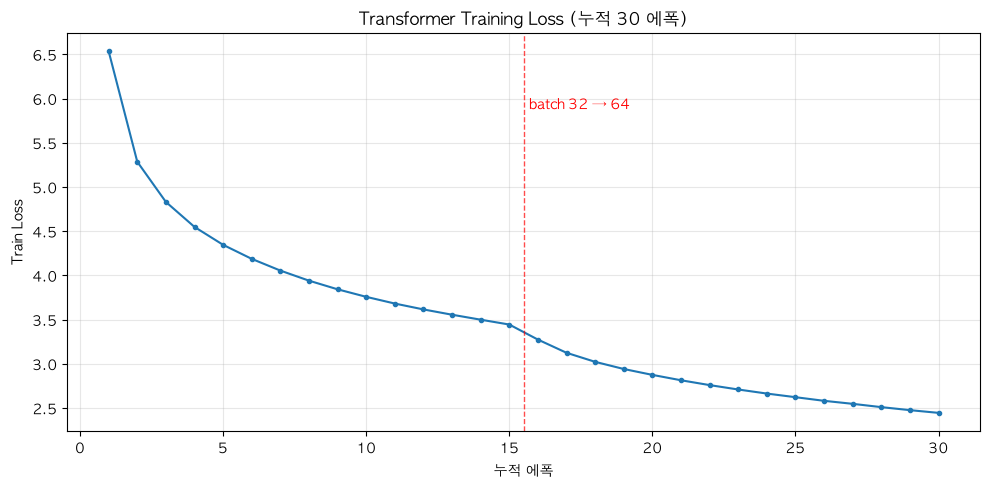

In [41]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 맥 기본 한글 폰트(AppleGothic) 설정
fontpath = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
fm.fontManager.addfont(fontpath)
fontprop = fm.FontProperties(fname=fontpath)
plt.rcParams["font.family"] = fontprop.get_name()
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

# 배치32(1~15회차) + 배치64(16~30회차) 전체 loss 기록
loss_history = [
    6.5351, 5.2853, 4.8307, 4.5480, 4.3455, 4.1868, 4.0543, 3.9403,
    3.8425, 3.7574, 3.6814, 3.6150, 3.5551, 3.4989, 3.4440,   # 배치32 구간 (1~15)
    3.2739, 3.1245, 3.0221, 2.9412, 2.8746, 2.8137, 2.7590, 2.7092,
    2.6633, 2.6223, 2.5812, 2.5471, 2.5098, 2.4757, 2.4449     # 배치64 구간 (16~30)
]

epochs = list(range(1, len(loss_history) + 1))

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss_history, marker='o', markersize=3, linewidth=1.5, color='#1f77b4')

# 배치가 바뀐 지점(15→16회차) 표시
plt.axvline(x=15.5, color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.text(15.7, max(loss_history)*0.9, 'batch 32 → 64', color='red', fontsize=10)

plt.title('Transformer Training Loss (누적 30 에폭)')
plt.xlabel('누적 에폭')
plt.ylabel('Train Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 

#### 1-15, 16-30회차 변화 추이(정성적, 정량적)

| 항목 | 내용 |
|---|---|
| **문장** | K1) 오바마는 대통령이다 |
| 1~15회차 정성적 변화 | obama 반복 붕괴(2~3회 중복 잦음), 원문과 무관한 수식어(democratic presidential race 등) 다수 |
| 16~30회차 정성적 변화 | 반복 크게 감소, 문장 구조 안정화. 다만 새로운 형태의 부가 명사구(meeting with obama 등)는 계속 등장 |
| 1~15회차 정량적 변화(BLEU) | 0.3672 |
| 16~30회차 정량적 변화(BLEU) | 0.4671 |
| **문장** | K2) 시민들은 도시 속에 산다 |
| 1~15회차 정성적 변화 | 지명 환각(san diego, san francisco 등) 지속, 두 지명이 한 문장에 동시 등장하는 모순 발생 |
| 16~30회차 정성적 변화 | 후반부(25회차 이후) 지명 환각 소멸, 단 핵심 서술어("산다")는 전 구간 미등장 |
| 1~15회차 정량적 변화(BLEU) | 0.1066 |
| 16~30회차 정량적 변화(BLEU) | 0.2481 |
| **문장** | K3) 커피는 필요 없다 |
| 1~15회차 정성적 변화 | coffee 중복 등장, "required to be required" 같은 동어반복 빈번 |
| 16~30회차 정성적 변화 | 반복 크게 감소, "no longer required"로 의미 정확도 향상 |
| 1~15회차 정량적 변화(BLEU) | 0.1562 |
| 16~30회차 정량적 변화(BLEU) | 0.1775 |
| **문장** | K4) 일곱 명의 사망자가 발생했다 |
| 1~15회차 정성적 변화 | seven이 특정 회차(7,10,11)에만 등장했다 사라지는 진동 반복 |
| 16~30회차 정성적 변화 | 거의 전 구간에서 seven 안정적으로 유지 |
| 1~15회차 정량적 변화(BLEU) | 0.1139 |
| 16~30회차 정량적 변화(BLEU) | 0.2268 |

#### 

#### 같은 배치 사이즈 64로 10 epoch 추가 

In [42]:
BATCH_SIZE = 64   # 그대로 유지
EPOCHS = 10        # 추가 10회 (누적 40회)

for epoch in range(EPOCHS):
    train_loss = train_epoch(transformer, enc_train, dec_train, optimizer, scheduler, BATCH_SIZE, device)
    loss_history.append(train_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} (누적 {len(loss_history)}번째), Train Loss: {train_loss:.4f}")
    
    for s in test_sentences:
        result, *_ = translate(s, transformer, ko_tokenizer, en_tokenizer, device)
        print(f"  {s} → {result}")
    print()
    
    torch.save(transformer.state_dict(), "transformer_checkpoint.pt")

  0%|          | 0/1181 [00:00<?, ?it/s]

Epoch 1/10 (누적 31번째), Train Loss: 2.4178
  오바마는 대통령이다. → obama is set to hold a meeting with obama .
  시민들은 도시 속에 산다. → they were part of the city s th birthday .
  커피는 필요 없다. → coffee is no longer required to find out the coffee line .
  일곱 명의 사망자가 발생했다. → seven people were killed in monday s clashes .



  0%|          | 0/1181 [00:00<?, ?it/s]

Epoch 2/10 (누적 32번째), Train Loss: 2.3876
  오바마는 대통령이다. → obama s aides are set to hold the senate .
  시민들은 도시 속에 산다. → they were part of the city s th century summit .
  커피는 필요 없다. → coffee is no longer required to be taken .
  일곱 명의 사망자가 발생했다. → seven deaths were reported in the disaster .



  0%|          | 0/1181 [00:00<?, ?it/s]

...

Epoch 8/10 (누적 38번째), Train Loss: 2.2406
  오바마는 대통령이다. → obama is the president elect to hold a senate vote at the house .
  시민들은 도시 속에 산다. → they were part of a new city in the city s th century .
  커피는 필요 없다. → coffee is no longer required to be taken away from the coffee house .
  일곱 명의 사망자가 발생했다. → seven people were killed in monday s shootings .



  0%|          | 0/1181 [00:00<?, ?it/s]

Epoch 9/10 (누적 39번째), Train Loss: 2.2211
  오바마는 대통령이다. → obama has the president elect to be the president s campaign .
  시민들은 도시 속에 산다. → they were presented to the urban structure in the city .
  커피는 필요 없다. → coffee is no necessary form of a new era in the coffee house .
  일곱 명의 사망자가 발생했다. → seven deaths were reported in monday s crash , with at least seven people dead .



  0%|          | 0/1181 [00:00<?, ?it/s]

Epoch 10/10 (누적 40번째), Train Loss: 2.2001
  오바마는 대통령이다. → obama is the president s campaign to hold the polls .
  시민들은 도시 속에 산다. → they were part of the city s th century mountain .
  커피는 필요 없다. → coffee is no longer required to be taken away from the coffee house .
  일곱 명의 사망자가 발생했다. → seven deaths were reported in the disaster .



In [44]:
def translate_v2(sentence, model, ko_tokenizer, en_tokenizer, device, max_len=50, length_penalty=0.1):
    # 문장이 길어질수록 eos(문장 끝) 토큰을 더 쉽게 함

    model.eval()

    # 1. 입력 문장을 토큰화하고 텐서로 변환
    src_ids = ko_tokenizer.encode_as_ids(sentence)      # 한국어 문장 → 토큰 ID 리스트
    src_tensor = torch.tensor([src_ids]).to(device)      # (1, src_len) 형태의 배치 텐서로 변환

    # 2. 인코더용 패딩 마스크 생성
    enc_mask = generate_padding_mask(src_tensor).to(device)

    with torch.no_grad():   # 추론 시에는 기울기 계산이 필요 없으므로 비활성화

        # 3. 인코더는 한 번만 (병렬 처리)
        enc_in = model.embedding(model.enc_emb, src_tensor)   # 임베딩 + positional encoding
        enc_out, _ = model.encoder(enc_in, enc_mask)             # 인코더 블록(N층) 통과 → 최종 인코더 출력

        dec_input = [1]              # 디코더 입력 시작
        dec_enc_attn_weights = None  # 마지막으로 계산된 cross-attention 가중치를 저장할 변수

        # 4. 디코더는 한 단어씩 순차적으로 생성
        for step in range(max_len):   # step: 지금 몇 번째 단어를 생성 중인지 (0부터 시작)
            dec_tensor = torch.tensor([dec_input]).to(device)              # 지금까지 만든 시퀀스 전체
            dec_mask = generate_causality_mask(len(dec_input)).to(device)   # 미래 토큰을 가리는 마스크

            dec_in = model.embedding(model.dec_emb, dec_tensor)   # 디코더 임베딩 + positional encoding
            # 디코더 블록(N층) 통과: masked self-attention + cross-attention(인코더 참조) + FFN
            dec_out, dec_attns, dec_enc_attns = model.decoder(dec_in, enc_out, enc_mask, dec_mask)

            logits = model.fc(model.final_norm(dec_out))   # 정규화 후 vocab_size 크기로 변환

            # length penalty 적용 부분
            # eos(id=2) 토큰의 점수에, 지금까지 만든 단어 수(step)에 비례한 보너스를 더함
            # 문장이 길어질수록 eos가 점점 더 선택되기 쉬워짐 (일찍 끝내도록 유도)
            logits[0, -1, 2] += length_penalty * step

            next_token = logits[0, -1].argmax().item()      # 마지막 위치의 예측 중 가장 확률 높은 토큰 선택

            if next_token == 2:               # eos_id(2)가 나오면 문장이 끝난 것이므로 종료
                dec_enc_attn_weights = dec_enc_attns
                break

            dec_input.append(next_token)       # 새로 예측한 토큰을 시퀀스 뒤에 추가
            dec_enc_attn_weights = dec_enc_attns   # attention 시각화를 위해 매번 갱신하며 저장

    result_ids = dec_input[1:]                        # bos 토큰은 제외하고
    result_text = en_tokenizer.decode(result_ids)      # 토큰 ID들을 실제 영어 문장으로 디코딩

    # 번역 결과 문장, 원본 토큰 ID, 생성된 전체 시퀀스, attention 가중치를 함께 반환
    return result_text, src_ids, dec_input, dec_enc_attn_weights

In [49]:
for penalty in [0.5, 1.0, 1.5, 2.0, 3.0]:
    print(f"=== length_penalty={penalty} ===")
    for s in test_sentences:
        result, *_ = translate_v2(s, transformer, ko_tokenizer, en_tokenizer, device, length_penalty=penalty)
        print(f"  {s} → {result}")
    print()

=== length_penalty=0.5 ===
  오바마는 대통령이다. → obama is the president elect to have a full day
  시민들은 도시 속에 산다. → they were part of the city s th century
  커피는 필요 없다. → coffee is no need to be
  일곱 명의 사망자가 발생했다. → seven deaths were reported in the disaster

=== length_penalty=1.0 ===
  오바마는 대통령이다. → obama is the president elect
  시민들은 도시 속에 산다. → they were part of the city
  커피는 필요 없다. → coffee is no need to be
  일곱 명의 사망자가 발생했다. → seven deaths were reported in the disaster

=== length_penalty=1.5 ===
  오바마는 대통령이다. → obama is the president
  시민들은 도시 속에 산다. → they were part of the
  커피는 필요 없다. → coffee is no need
  일곱 명의 사망자가 발생했다. → seven deaths were reported

=== length_penalty=2.0 ===
  오바마는 대통령이다. → obama is the president
  시민들은 도시 속에 산다. → they were part of the
  커피는 필요 없다. → coffee is no need
  일곱 명의 사망자가 발생했다. → seven deaths were reported

=== length_penalty=3.0 ===
  오바마는 대통령이다. → obama is the president
  시민들은 도시 속에 산다. → they were part of
  커피는 필요 없다. → coffee is no
  일곱 명의 사망자가 발생

##### 1. length_penalty를 0.05, 0.1, 0.15, 0.2로 줘봤는데 → 아무 변화 없음
##### 2. 0.5, 1.0, 2.0, 3.0까지 세게 줘보니 → 1.0에서야 드디어 문장이 짧아지기 시작
##### 3. "왜 이렇게 높은 점수를 주어야만 효과가 있었을까?" 
##### 
##### 근거: logits = model.fc(model.final_norm(dec_out))   # 최종 정규화 후 vocab_size 크기로 변환
##### next_token = logits[0, -1].argmax().item()    # 마지막 위치의 예측 중 가장 확률 높은 토큰 선택
#####
##### ① Cross Entropy Loss를 사용하면 모델은 정답 토큰의 확률을 높이는 방향으로 학습한다.
#####                    
##### ② 학습이 충분히 진행되면 모델이 특정 정답 토큰에 매우 높은 확률을 부여할 수 있다.
##### → 과도한 확신(overconfidence)이 발생할 수도 있음
#####                      
##### ③ 예를 들어 away= 98%, EOS= 0.3%라면 away를 선택한다.
##### 
##### 높은 length penalty에서 생성 결과가 개선되었다는 것은 모델의 특정 토큰에 대한 과도한 확신이 존재했을 가능성을 이야기한다. 
##### 특히 EOS 토큰의 예측 확률이 낮고 다른 토큰의 확률이 지나치게 높다면, 
##### length penalty만으로 해결하기보다는 label smoothing과 같은 학습 단계의 정규화 기법을 적용하여 모델의 과도한 확신을 완화할 필요가 있다.
##### label smoothing은 은 학습 단계에서 정답을 100%로 설정하지 않고,정답 토큰에 높은 확률을 주되 나머지 확률을 다른 토큰에도 분산시키는 방법이다.
##### llabel smoothing은 추론 단계가 아니라 모델을 학습시키는 단계에서 적용해야 하는 방법이라 현 시점에 맞는 length penalty로 결과를 수정하고자 한다.

##### 

In [50]:
# 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fontpath = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
fm.fontManager.addfont(fontpath)
fontprop = fm.FontProperties(fname=fontpath)
plt.rcParams["font.family"] = fontprop.get_name()
plt.rcParams["axes.unicode_minus"] = False

In [52]:
def plot_attention(sentence, model, ko_tokenizer, en_tokenizer, device, length_penalty=2.0):

    # length_penalty를 적용해 번역 수행, attention 가중치 받음
    result_text, src_ids, dec_input, dec_enc_attns = translate_v2(
        sentence, model, ko_tokenizer, en_tokenizer, device, length_penalty=length_penalty
    )

    # 마지막 디코더 블록의 attention을, 8개 head에 대해 평균 내어 하나의 값으로 만듦
    attn = dec_enc_attns[-1][0].mean(dim=0).cpu().numpy()   # [tgt_len, src_len] 형태

    # 토큰 ID를 실제 서브워드 조각으로 변환해서 축 라벨로 사용
    src_pieces = [ko_tokenizer.id_to_piece(i) for i in src_ids]
    tgt_pieces = [en_tokenizer.id_to_piece(i) for i in dec_input[1:]]   # bos 제외

    fig, ax = plt.subplots(figsize=(7, 7))
    im = ax.matshow(attn[:len(tgt_pieces), :len(src_pieces)], cmap='viridis')

    ax.set_xticks(range(len(src_pieces)))
    ax.set_xticklabels(src_pieces, rotation=90, fontproperties=fontprop)
    ax.set_yticks(range(len(tgt_pieces)))
    ax.set_yticklabels(tgt_pieces, fontproperties=fontprop)

    plt.title(f"{sentence}  →  {result_text}", fontproperties=fontprop, pad=20)
    plt.xlabel("한국어 (source)", fontproperties=fontprop)
    plt.ylabel("영어 (target)", fontproperties=fontprop)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    return result_text

최종 번역 결과 및 Attention Map (length_penalty=1.0)


/var/folders/z_/64y20xy111n7gy3bp9tvq97c0000gn/T/ipykernel_12949/3807726187.py:27: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  plt.tight_layout()
/opt/anaconda3/envs/nlp_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


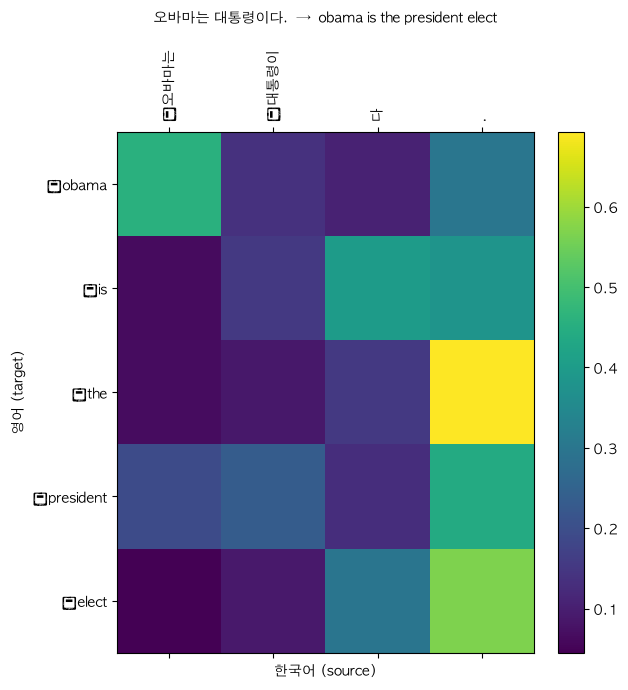

오바마는 대통령이다. → obama is the president elect



/var/folders/z_/64y20xy111n7gy3bp9tvq97c0000gn/T/ipykernel_12949/3807726187.py:27: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  plt.tight_layout()
/opt/anaconda3/envs/nlp_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


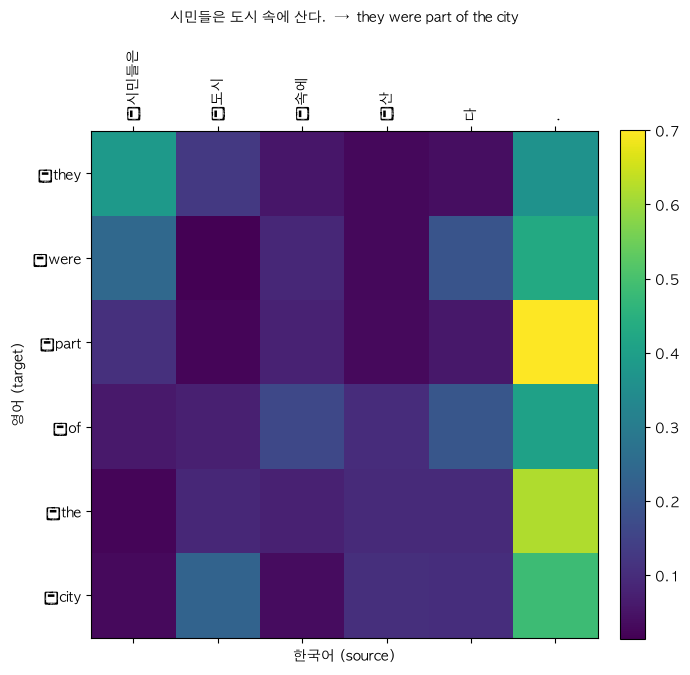

시민들은 도시 속에 산다. → they were part of the city



/var/folders/z_/64y20xy111n7gy3bp9tvq97c0000gn/T/ipykernel_12949/3807726187.py:27: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  plt.tight_layout()
/opt/anaconda3/envs/nlp_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


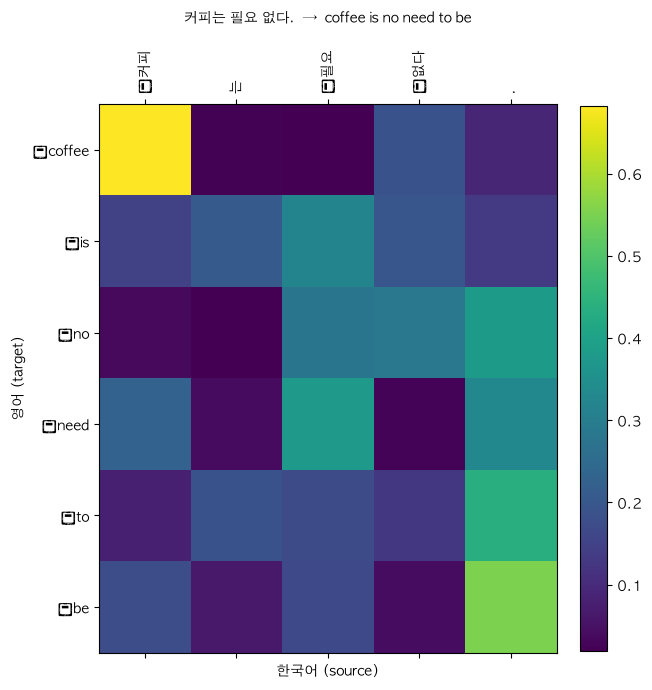

커피는 필요 없다. → coffee is no need to be



/var/folders/z_/64y20xy111n7gy3bp9tvq97c0000gn/T/ipykernel_12949/3807726187.py:27: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  plt.tight_layout()
/opt/anaconda3/envs/nlp_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


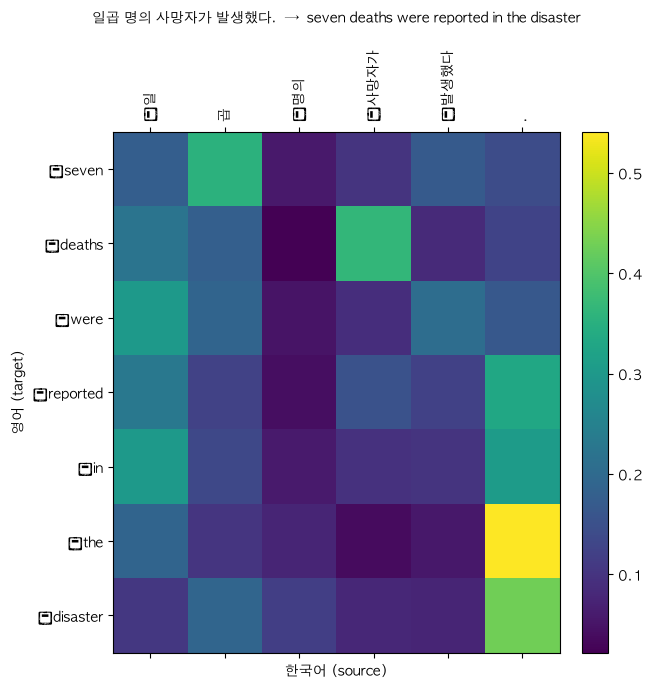

일곱 명의 사망자가 발생했다. → seven deaths were reported in the disaster



In [54]:
print("=" * 60)
print("최종 번역 결과 및 Attention Map (length_penalty=1.0)")
print("=" * 60)

for s in test_sentences:
    result = plot_attention(s, transformer, ko_tokenizer, en_tokenizer, device, length_penalty=1.0)
    print(f"{s} → {result}\n")

## Attention Map 분석 (length_penalty=1.0)

| 문장 | 생성 단어 | 집중 부분 | 평가 |
|---|---|---|---|
| K1) obama is the president elect | obama | 오바마 (중간, 초록) | 양호 |
| K1) obama is the president elect | is | 다, . 에 고르게 분산 (중간) | 다소 모호 |
| K1) obama is the president elect | the | . (가장 밝은 노란색) | 부적절, 마침표 과의존 |
| K1) obama is the president elect | president | . (중간, 초록) | 약함 |
| K1) obama is the president elect | elect | . (밝은 연두) | 약함, 마침표 의존 |
| K1) obama is the president elect | **종합** | - | 추가된 "elect"도 결국 마침표에 의존해 생성됨 |
| K2) they were part of the city | they | 시민들은 (중간, 초록) | 양호 |
| K2) they were part of the city | were | . (중간, 초록) | 약함 |
| K2) they were part of the city | part | . (가장 밝은 노란색) | 부적절 |
| K2) they were part of the city | of | . (중간, 초록) | 약함 |
| K2) they were part of the city | the | . (밝은 연두) | 부적절 |
| K2) they were part of the city | city | 도시 (파란색, 약간 상승) + . (초록, 여전히 더 높음) | 미미하게 개선, 그러나 여전히 마침표가 더 우세 |
| K2) they were part of the city | **종합** | - | 문장이 "city"까지 늘어나면서 "도시"에 대한 미약한 attention이 생기긴 했지만, 결정적인 대응은 여전히 형성되지 않음 |
| K3) coffee is no need to be | coffee | 커피 (가장 밝은 노란색) | 완벽, 정확히 대응 |
| K3) coffee is no need to be | is | 여(필요) (중간) | 양호 |
| K3) coffee is no need to be | no | . (중간) | 약함 |
| K3) coffee is no need to be | need | 여(필요) (중간) | 양호 |
| K3) coffee is no need to be | to | . (중간) | 약함 |
| K3) coffee is no need to be | be | . (밝은 연두) | 약함, 마침표 의존 |
| K3) coffee is no need to be | **종합** | - | 초반(coffee, need)은 정확한 대응 유지, 후반부(to, be)로 갈수록 마침표 의존 심화 — "미완성 느낌"의 원인 |
| K4) seven deaths were reported in the disaster | seven | 명 (중간, 초록) | 양호, 단위어와 연관 |
| K4) seven deaths were reported in the disaster | deaths | 사망자가 (밝은 초록) | 정확, 핵심 단어와 대응 |
| K4) seven deaths were reported in the disaster | were | 명 (중간) | 양호 |
| K4) seven deaths were reported in the disaster | reported | . (중간) | 약함 |
| K4) seven deaths were reported in the disaster | in | 명 (중간) | 다소 산만 |
| K4) seven deaths were reported in the disaster | the | . (가장 밝은 노란색) | 부적절 |
| K4) seven deaths were reported in the disaster | disaster | . (밝은 연두) | 약함, 마침표 의존 |
| K4) seven deaths were reported in the disaster | **종합** | - | 문장 초반(seven, deaths)의 정확한 대응은 유지되나, 추가된 "in the disaster" 구간은 원문과의 명확한 연결 없이 마침표에 의존해 생성됨 |

## 종합 패턴 — 4개 문장을 관통하는 공통 발견

| 항목 | 내용 |
|---|---|
| 발견 1 | 핵심 명사(고유명사, 사건 관련어)는 penalty 값과 무관하게 정확함 |
| 발견 1 근거 | K3의 "coffee", K4의 "deaths"처럼 원문에 뚜렷한 대응어가 있는 단어는 항상 정확히 짚어냄 |
| 발견 2 | 기능어(the, of, is, to 등)는 마침표(.)에 의존하는 경향이 반복됨 |
| 발견 2 근거 | K1의 "the", K2의 "part/the", K3의 "to/be", K4의 "the" — 대부분 원문 특정 단어보다 문장 종결 부호에 attention이 쏠림 |
| 발견 3 | penalty로 새로 추가된 단어일수록 attention 근거가 약함 |
| 발견 3 근거 | K1의 "elect", K2의 "city", K4의 "in the disaster" — 늘어난 구간 대부분이 원문과의 명확한 연결 없이 생성됨 |
| 발견 4 | 문장 초반부는 강하고 정확, 후반부로 갈수록 약해지는 공통 패턴 |
| 발견 4 근거 | 4개 문장 모두 초반(핵심 명사)은 attention이 뚜렷하나, 후반으로 갈수록 마침표 의존이 심화됨 |
| 발견 5 | K2(시민들은 도시 속에 산다)가 가장 취약함 |
| 발견 5 근거 | "city"에 약한 반응은 보이나, 핵심 서술어("산다")에 대응하는 원문 위치 자체가 끝내 형성되지 않음 |